# EM Algorithm for Gaussian Mixture Models
A Gaussian Mixture Model (GMM) is a probabilistic model that assumes that the observed data is generated from a mixture of several Gaussian distributions. Instead of representing the entire dataset by a single Gaussian distribution, GMM models the data as a weighted sum of multiple Gaussian components, allowing it to describe complex and multi-modal distributions.
Each Gaussian component can be interpreted as representing one cluster in the data, and the mixing coefficients determine the relative contribution of each cluster.

The parameters of the model are

$$
\theta=
\{\pi_1,\ldots,\pi_K,
\mu_1,\ldots,\mu_K,
\Sigma_1,\ldots,\Sigma_K\}.
$$

Given a dataset

$$
X=\{x_1,x_2,\ldots,x_N\},
\qquad
x_n\in\mathbb{R}^d,
$$

the objective is to estimate the parameters $\theta$ that maximize the likelihood of observing the data.

The likelihood of observing all the data points under a Gaussian Mixture Model (GMM) is
$$
l(\theta)
=
\prod_{n=1}^{N}
\left(
\sum_{m=1}^{K}
\pi_m \,
\mathcal{N}\!\left(x_n \mid \mu_m,\Sigma_m\right)
\right)
$$
where
$N$ is the number of data points,
$K$ is the number of Gaussian components,
$\pi_k$ is the mixing coefficient of the $k^{\rm th}$ Gaussian,
$\mu_k$ and $\Sigma_k$ are the mean vector and covariance matrix of the $k^{\rm th}$ Gaussian.

Taking the logarithm converts the product into a sum:

$$
log(l(\theta)) 
=
\sum_{n=1}^{N}
log 
\left(
\sum_{m=1}^{K}
\pi_{m} \,
\mathcal{N}\!\left(x_n \mid \mu_m ,\Sigma_m\right)
\right)
$$
Our goal is to maximize $\mathcal L(\theta)$ with respect to the mean vector $\mu^k$ of the $k^{\rm th}$ component,

$$
\frac{\partial \mathcal{L}(\theta)} {\partial \mu^{k}} = ?
$$
Here Numerator is scalar while the denominator is a vector of size d x 1. Thus we consider the partial derivative w.r.t jth component of $\mu^{k}$:

$$
\frac{\partial \mathcal{L}(\theta)} {\partial \mu^{k}_{j}}
=
\sum_{n=1}^{N}
\frac{1}{\left(
\sum_{m=1}^{K}
\pi_{m} \,
\mathcal{N}\!\left(x_n \mid \mu_m ,\Sigma_m\right)
\right)}
\pi_{k}
\frac{\partial \mathcal{N}}{\partial \mu_{j}^{k}}
$$
$$
\frac{\partial \mathcal{N}}{\partial \mu_{j}^{k}} = ?
$$

The multivariate gaussian distribution is :

$$
\mathcal{N} 
=
\frac{1}{(2\pi)^{k/2}}
det(\Sigma)^{-1/2}
e^{
\frac{-1}{2}
\left( x^n - \mu^{k} \right)^{T} \Sigma^{-1} \left( x^n - \mu^{k} \right)
}
$$
Only the exponential term depends on $\mu^k$, so
\begin{align}
\frac{\partial \mathcal{N}}{\partial \mu_{j}^{k}}
&=
\mathcal{N}\,
\frac{\partial}{\partial \mu_{j}^{k}}
\left[
-\frac{1}{2}
\sum_{i=1}^{d}
\sum_{l=1}^{d}
(x_i^n-\mu_i^k)
(\Sigma^{-1})_{il}
(x_l^n-\mu_l^k)
\right]
\\[1ex]
&=
-\frac{\mathcal{N}}{2}
\sum_{i=1}^{d}
\sum_{l=1}^{d}
\Bigg[
\frac{\partial (x_i^n-\mu_i^k)}
{\partial \mu_j^k}
(\Sigma^{-1})_{il}
(x_l^n-\mu_l^k)
\\
&\qquad\qquad\qquad\qquad
+
(x_i^n-\mu_i^k)
(\Sigma^{-1})_{il}
\frac{\partial (x_l^n-\mu_l^k)}
{\partial \mu_j^k}
\Bigg]
\\[1ex]
&=
-\frac{\mathcal{N}}{2}
\sum_{i=1}^{d}
\sum_{l=1}^{d}
\Big[
(-\delta_{ij})
(\Sigma^{-1})_{il}
(x_l^n-\mu_l^k)
\\
&\qquad\qquad\qquad\qquad
+
(x_i^n-\mu_i^k)
(\Sigma^{-1})_{il}
(-\delta_{lj})
\Big]
\\[1ex]
&=
\frac{\mathcal{N}}{2}
\left[
\sum_{l=1}^{d}
(\Sigma^{-1})_{jl}
(x_l^n-\mu_l^k)
+
\sum_{i=1}^{d}
(x_i^n-\mu_i^k)
(\Sigma^{-1})_{ij}
\right].
\end{align}


Since $\Sigma$ is symmetric.
$$
\frac{\partial \mathcal{N}}{\partial \mu_{j}^{k}}
=
\mathcal{N}
\sum_{l=1}^{d}
(\Sigma^{-1})_{jl}
(x_l^n-\mu_l^k).
$$


$$
\boxed{
\frac{\partial \mathcal{N}}{\partial \mu^{k}}
=
\mathcal{N}\,
\Sigma^{-1}(x^n-\mu^k)
}
$$

$$
\text{Since the size of }\Sigma^{-1}\text{ is }d\times d\text{ and that of }(x^n-\mu^k)\text{ is }d\times 1,\,
\Sigma^{-1}(x^n-\mu^k)\text{ is of size }d\times 1,
\text{ matching the size of }
\frac{\partial \mathcal N}{\partial \mu^k}.
$$

$$
\frac{\partial \mathcal L(\theta)}
{\partial \mu_j^k}
=
\sum_{n=1}^N
\frac{
\pi_k\,
\mathcal N(x_n\mid\mu_k,\Sigma_k)
\left[
\Sigma_k^{-1}(x_n-\mu_k)
\right]_j
}
{
\sum_{m=1}^K
\pi_m\,
\mathcal N(x_n\mid\mu_m,\Sigma_m)
}.
$$
In Matrix Notation:
$$
\boxed{
\frac{\partial \mathcal L(\theta)}
{\partial \mu^k}
=
\sum_{n=1}^N
\frac{
\pi_k\,
\mathcal N(x_n\mid\mu_k,\Sigma_k)
}
{
\sum_{m=1}^K
\pi_m\,
\mathcal N(x_n\mid\mu_m,\Sigma_m)
}
\,
\Sigma_k^{-1}(x_n-\mu_k)
}
$$
Define responsibilty:
$$
r_{nk}
=
\frac{
\pi_k\,
\mathcal N(x_n\mid\mu_k,\Sigma_k)
}
{
\sum_{m=1}^K
\pi_m\,
\mathcal N(x_n\mid\mu_m,\Sigma_m)
},
$$
$$
\boxed{
\frac{\partial \mathcal L(\theta)}
{\partial \mu_k}
=
\sum_{n=1}^N
r_{nk}\,
\Sigma_k^{-1}(x_n-\mu_k)
}.
$$

where

$$
r_{nk}\equiv\texttt{rnk[n,k]},\qquad
rnk\in\mathbb R^{N\times K},\qquad
x\in\mathbb R^{N\times d},\qquad
\mu\in\mathbb R^{K\times d}.
$$

Setting the derivative to zero,

$$
\sum_{n=1}^N
r_{nk}\,
\Sigma_k^{-1}(x_n-\mu_k)=0.
$$

Since $\Sigma_k^{-1}$ does not depend on $n$ and is invertible, multiplying both sides by $\Sigma_k$ gives

$$
\sum_{n=1}^{N}
r_{nk}(x_n-\mu_k)=0.
$$

Expanding the summation,

$$
\sum_{n=1}^{N}r_{nk}x_n
-
\mu_k\sum_{n=1}^{N}r_{nk}=0,
$$

which yields the maximum-likelihood estimate

$$
\boxed{
\mu_k
=
\frac{\sum_{n=1}^{N}r_{nk}x_n}
{\sum_{n=1}^{N}r_{nk}}.
}
$$

Similarly, maximizing the expected complete-data log-likelihood with respect to the covariance matrices and mixing coefficients gives

$$
\boxed{
\Sigma_k
=
\frac{\sum_{n=1}^{N}
r_{nk}(x_n-\mu_k)(x_n-\mu_k)^T}
{\sum_{n=1}^{N}r_{nk}},
}
$$

and

$$
\boxed{
\pi_k
=
\frac{1}{N}
\sum_{n=1}^{N}r_{nk}.
}
$$

Notice that the responsibilities $r_{nk}$ themselves depend on the current parameter estimates through

$$
r_{nk}
=
\frac{\pi_k\,
\mathcal N(x_n\mid\mu_k,\Sigma_k)}
{\sum_{j=1}^{K}
\pi_j\,
\mathcal N(x_n\mid\mu_j,\Sigma_j)}.
$$

Consequently, the update equations for $\mu_k$, $\Sigma_k$, and $\pi_k$ cannot be solved independently in a single step. Instead, the parameters are estimated using the **Expectation-Maximization (EM)** algorithm, which iteratively alternates between:

1. **Expectation (E-step):** Compute the responsibilities $r_{nk}$ using the current estimates of $\{\mu_k,\Sigma_k,\pi_k\}$.

2. **Maximization (M-step):** Update the parameters using

$$
\mu_k
=
\frac{\sum_n r_{nk}x_n}{\sum_n r_{nk}},
\qquad
\Sigma_k
=
\frac{\sum_n r_{nk}(x_n-\mu_k)(x_n-\mu_k)^T}
{\sum_n r_{nk}},
\qquad
\pi_k
=
\frac{1}{N}\sum_n r_{nk}.
$$

These two steps are repeated until the log-likelihood (or equivalently the parameter estimates) converges.

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def gaussian(x, amp, mean, sigma):
    return amp/(sigma*np.sqrt(2*np.pi)) * np.exp(
        -0.5*((x-mean)/sigma)**2
    )

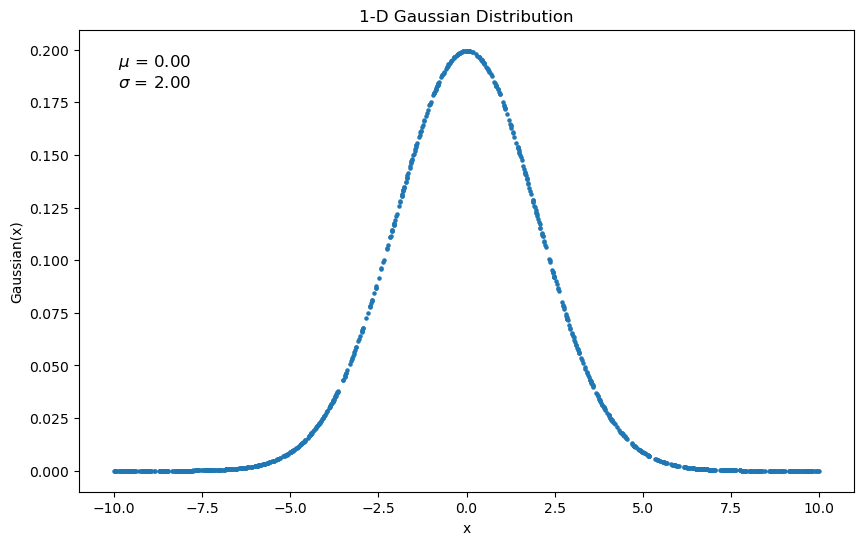

In [3]:
npoints = 1000

x = np.random.uniform(-10, 10, npoints)

amplitude = 1.0
sigma = 2.0
mean = 0.0

y = gaussian(x, amplitude, mean, sigma)

# Plot
figure = plt.figure(figsize=(10, 6))
axis = figure.add_subplot(1, 1, 1)

axis.scatter(x, y, s=5)
axis.set_xlabel("x")
axis.set_ylabel("Gaussian(x)")
axis.set_title("1-D Gaussian Distribution")

textstr = f"$\\mu$ = {mean:.2f}\n$\\sigma$ = {sigma:.2f}"
axis.text(
    0.05, 0.95,
    textstr,
    transform=axis.transAxes,
    fontsize=12,
    verticalalignment='top')

plt.show()


In [1]:
def bivariate_gaussian(x, y,
                       ampl,
                       mean_x, mean_y,
                       sigma_x, sigma_y,
                       rho):

    z = (
        ((x - mean_x)**2) / sigma_x**2
        + ((y - mean_y)**2) / sigma_y**2
        - 2 * rho * (x - mean_x) * (y - mean_y)
          / (sigma_x * sigma_y)
    )

    norm = ampl / (
        2 * np.pi * sigma_x * sigma_y
        * np.sqrt(1 - rho**2)
    )

    return norm * np.exp(
        -z / (2 * (1 - rho**2))
    )

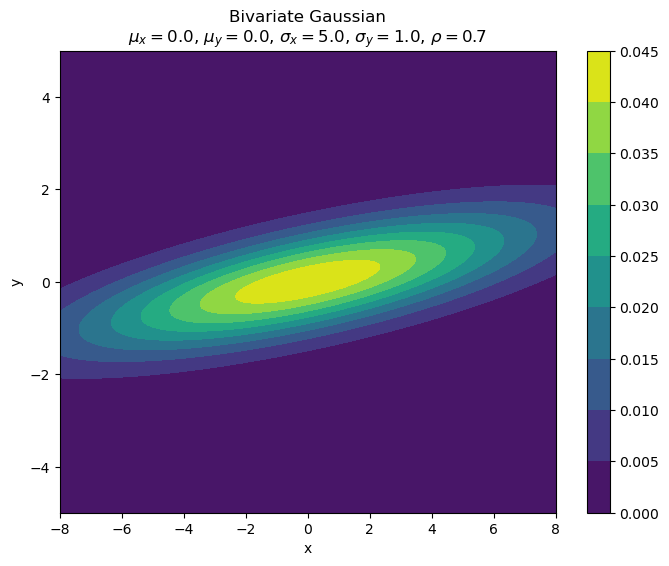

In [5]:
mean_x = 0.0
mean_y = 0.0
sigma_x = 5.0
sigma_y = 1.0
rho = 0.7
ampl = 1.0

x = np.linspace(-8, 8, 200)
y = np.linspace(-5, 5, 200)

X, Y = np.meshgrid(x, y)

Z = bivariate_gaussian(
        X, Y,
        ampl,
        mean_x, mean_y,
        sigma_x, sigma_y,
        rho
)
fig, ax = plt.subplots(figsize=(8,6))

cont = ax.contourf(X, Y, Z, levels=10)
plt.colorbar(cont, ax=ax)

ax.set_xlabel('x')
ax.set_ylabel('y')

ax.set_title(
    rf'Bivariate Gaussian'
    '\n'
    rf'$\mu_x={mean_x}$, $\mu_y={mean_y}$, '
    rf'$\sigma_x={sigma_x}$, $\sigma_y={sigma_y}$, '
    rf'$\rho={rho}$'
)

plt.show()

# 1-D EM Algorithm

In [6]:
# Generate data
x1 = np.random.normal(loc=-5.0,scale=1.0,size=300)
x2 = np.random.normal(loc=0.0,scale=0.8,size=400)
x3 = np.random.normal(loc=6.0,scale=1.5,size=300)

x = np.concatenate([x1,x2,x3])
np.random.shuffle(x)
y = np.zeros(x.shape[0])


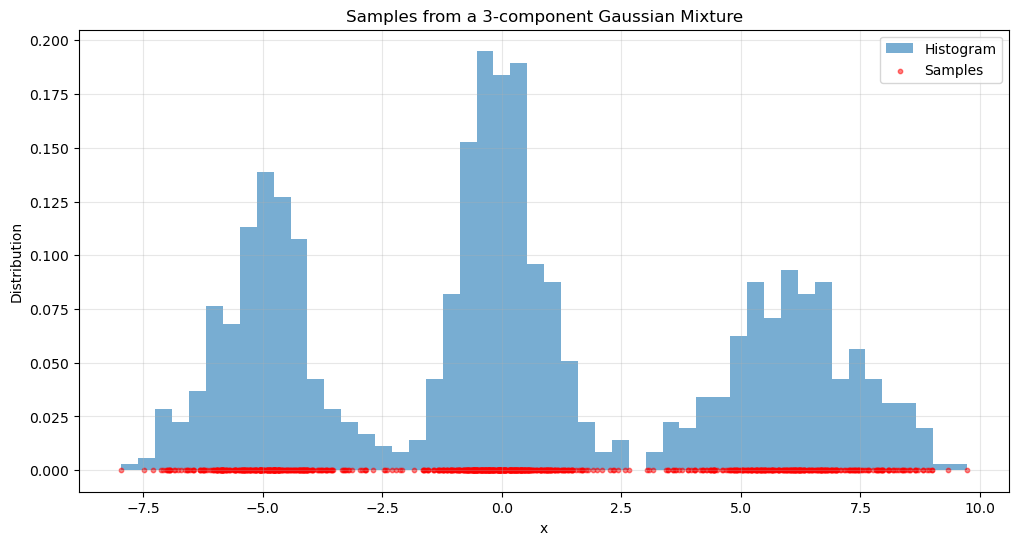

In [7]:
plt.figure(figsize=(12,6))

plt.hist(x, bins=50, density=True, alpha=0.6, label='Histogram')

plt.scatter(x,y, c='red', s=10, alpha=0.5, label='Samples')

plt.xlabel('x')
plt.ylabel('Distribution')
plt.title('Samples from a 3-component Gaussian Mixture')
plt.ylim(-0.01, None)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [8]:
# Initialization of parameters
K = 3
mu = [-2,0,5]
sigmas = [1,1,1]
pi = [1/3,1/3,1/3]


In [9]:
# Compute Probabilites
pnk = np.zeros((x.shape[0], K))

pnk[:,0] = norm.pdf(x, loc=mu[0], scale=sigmas[0])
pnk[:,1] = norm.pdf(x, loc=mu[1], scale=sigmas[1])
pnk[:,2] = norm.pdf(x, loc=mu[2], scale=sigmas[2])

NameError: name 'norm' is not defined

In [ ]:
pnk[:5]

In [ ]:
weighted_pnk = pnk * pi
weighted_pnk[:5]

In [ ]:
d = weighted_pnk.sum(axis=1) # denominator
d.shape

In [ ]:
# responsibilities
rnk = weighted_pnk / d[:,None]

In [ ]:
rnk.sum(axis=1)[:5]

In [ ]:
# Compute Nk
Nk = rnk.sum(axis=0)
Nk

In [ ]:
Nk.sum() # should be ~ 1000

In [ ]:
mu_new = (rnk * x[:,None]).sum(axis=0) / Nk

In [ ]:
mu_new

In [ ]:
# Update the variances
var_new = (rnk * (x[:,None] - mu_new)**2 ).sum(axis=0) / Nk
sigma_new = np.sqrt(var_new)

In [ ]:
sigma_new

In [ ]:
pi_new = Nk / 1000

In [ ]:
pi_new

# Full Implementation

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from matplotlib.animation import FuncAnimation
from IPython.display import HTML


# Generate data

np.random.seed(42)
x1 = np.random.normal(loc=-3.0,scale=1.5,size=300)
x2 = np.random.normal(loc=0.0,scale=0.8,size=400)
x3 = np.random.normal(loc=6.0,scale=1.0,size=300)

x = np.concatenate([x1,x2,x3])
N = x.shape[0]

# Initialization
K = 3
mu = np.array([-7.0,1.0,3.0])
sigma = np.array([1.0,1.0,1.0])
pi = np.array([1/3.,1/3.,1/3.])

logL = []
mu_all = []
sigma_all = []
pi_all = []

mu_all = [mu.copy()]
sigma_all = [sigma.copy()]
pi_all = [pi.copy()]

# EM Iteration
NIter = 30


for i in range(NIter):
    pnk = np.zeros((N,K))
    pnk[:,0] = norm.pdf(x,loc=mu[0],scale=sigma[0])
    pnk[:,1] = norm.pdf(x,loc=mu[1],scale=sigma[1])
    pnk[:,2] = norm.pdf(x,loc=mu[2],scale=sigma[2])
    
    weighted_pnk = pnk * pi
    d = weighted_pnk.sum(axis=1)
    rnk = weighted_pnk / d[:,None]

    Nk = rnk.sum(axis=0)

    mu_new = (rnk * x[:,None]).sum(axis=0) / Nk
    sigma_new = (rnk * (x[:,None] - mu_new)**2).sum(axis=0) / Nk
    sigma_new = np.sqrt(sigma_new)
    pi_new = Nk / N

     # Log-likelihood
    logL.append(np.sum(np.log(d)))
    mu_all.append(mu_new.copy())
    sigma_all.append(sigma_new.copy())
    pi_all.append(pi_new.copy())
    
    
    # Update parameters
    mu = mu_new
    sigma = sigma_new
    pi = pi_new
    
    print(f"Iter: {i+1},mu: {mu}, sigma: {sigma},pi: {pi}")
   
# Final parameters

print("\nFinal parameters")
print("mu    =", mu)
print("sigma =", sigma)
print("pi    =", pi)



In [ ]:
    
# Plotting and animation
fig = plt.figure(figsize=(15,6))
axis1 = fig.add_subplot(1,2,1)
axis2 = fig.add_subplot(1,2,2)

xgrid = np.linspace(x.min()-1,x.max()+1,N)


def update(frame):

    axis1.clear()
    axis2.clear()

    axis1.set_xlim(x.min()-1, x.max()+1)
    axis1.set_ylim(-0.03, 0.25)
    axis2.set_xlim(1, NIter)
    axis2.set_ylim(min(logL), max(logL)+100)

    mu = mu_all[frame]
    sigma = sigma_all[frame]
    pi = pi_all[frame]


    axis1.hist(x,bins=50,alpha=0.4,density=True,label='hist')
    axis1.scatter(x,np.zeros(N)-0.01,s=10,label='Data')


    gmm = np.zeros_like(xgrid)

    for ix in range(K):
        y = pi[ix] * norm.pdf(xgrid,loc=mu[ix],scale=sigma[ix])
        axis1.plot(xgrid, y, lw=2, label=f"Gaussian {ix+1}")
        gmm += y
        
    axis1.plot(xgrid, gmm, lw=2, label="GMM",c="black")

    axis1.set_xlabel("x")
    axis1.set_ylabel("Density")
    axis1.set_title("Gaussian Mixture Model (EM)")
    
    axis1.text(0.62, 0.98,
    f"Iter: {frame+1}\n"
    f"mu: {np.round(mu,2)}\n"
    f"sigma: {np.round(sigma,2)}\n"
    f"pi: {np.round(pi,2)}\n",
    transform=axis1.transAxes, va='top',bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    axis1.legend(loc='upper left')


    axis2.plot(np.arange(1,frame+2),logL[:frame+1],marker='o')
    axis2.set_xlabel("Iteration")
    axis2.set_ylabel("Log-Likelihood")
    axis2.set_title("EM Convergence")
    axis2.grid(True)

    plt.tight_layout()

animate = FuncAnimation(fig, update, frames=NIter, interval=300)
HTML(animate.to_jshtml())



In [ ]:
animate.save("1dEM.gif")

# 2D EM Algorithm

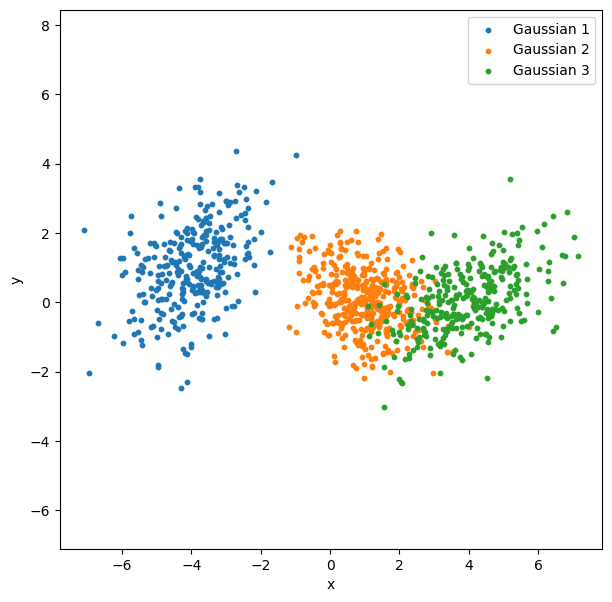


Final parameters
mu    = [[-3.97766642  1.00580774]
 [ 0.99009576  0.07816   ]
 [ 3.93715962  0.06135299]]
sigma = [[[ 0.96816788  0.49380759]
  [ 0.49380759  1.41566586]]

 [[ 0.80627528 -0.23176824]
  [-0.23176824  0.73567665]]

 [[ 1.48500426  0.59137321]
  [ 0.59137321  0.88833997]]]
pi    = [0.30018918 0.40286195 0.29694887]


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Generate data
np.random.seed(42)

#mu_true = np.array([[-4,-3],[0,3],[5,-1]])
mu_true = np.array([[-4,1],[1,0],[4,0]])

sigma_true = np.array([[[1.0,0.5],[0.5,1.5]],[[0.8,-0.3],[-0.3,0.8]],[[1.5,0.7],[0.7,1.0]]])

x1 = np.random.multivariate_normal(mu_true[0],sigma_true[0],300)
x2 = np.random.multivariate_normal(mu_true[1],sigma_true[1],400)
x3 = np.random.multivariate_normal(mu_true[2],sigma_true[2],300)


plt.figure(figsize=(7,7))
plt.scatter(x1[:,0], x1[:,1], s=10, label='Gaussian 1')
plt.scatter(x2[:,0], x2[:,1], s=10, label='Gaussian 2')
plt.scatter(x3[:,0], x3[:,1], s=10, label='Gaussian 3')
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.show()



x = np.concatenate([x1,x2,x3])
N = x.shape[0]

# Initialization
K = 3
mu = np.array([[-6,-2],[0,2],[6,0]])
sigma = np.array([
    [[1.,0.],[0.,1.]],
    [[1.,0.],[0.,1.]],
    [[1.,0.],[0.,1.]]
])


pi = np.array([1/3.,1/3.,1/3.])

logL = []
mu_all = []
sigma_all = []
pi_all = []

mu_all = [mu.copy()]
sigma_all = [sigma.copy()]
pi_all = [pi.copy()]

# EM Iteration
NIter = 30


for i in range(NIter):
    pnk = np.zeros((N,K))
    pnk[:,0] = multivariate_normal.pdf(x,mean=mu[0],cov=sigma[0])
    pnk[:,1] = multivariate_normal.pdf(x,mean=mu[1],cov=sigma[1])
    pnk[:,2] = multivariate_normal.pdf(x,mean=mu[2],cov=sigma[2])
    
    weighted_pnk = pnk * pi
    d = weighted_pnk.sum(axis=1)
    rnk = weighted_pnk / d[:,None]
    
    Nk = rnk.sum(axis=0)

    # Mean Update
    mu_new = (rnk[:,:,None] * x[:,None,:]).sum(axis=0) / Nk[:,None]
    #rnk - 1000,3
    #x - 1000,2
    #rnk * x - 1000,3,2
    # Use brodcasting 1000,3,1 for rnk
    # 1000,1,2 for x
    # numerator  then has shape 3,2 while N has (3,) so add extra dimension to N too.


    Nk = rnk.sum(axis=0)
    
    # Covariance Update
    
    diff = x[:,None,:] - mu_new[None,:,:]
    sigma_new = (rnk[:,:,None,None] * diff[:,:,:,None] * diff[:,:,None,:]).sum(axis=0) / Nk[:,None,None]

    ##rnk.shape        = (1000,3)
    ##Nk.shape         = (3,)
    ##diff.shape       = (1000,3,2)

    ##rnk[:,:,None,None].shape = (1000,3,1,1)
    ##diff[:,:,:,None].shape   = (1000,3,2,1)
    ##diff[:,:,None,:].shape   = (1000,3,1,2)
    pi_new = Nk / N

     # Log-likelihood
    logL.append(np.sum(np.log(d)))
    mu_all.append(mu_new.copy())
    sigma_all.append(sigma_new.copy())
    pi_all.append(pi_new.copy())
    
    
    # Update parameters
    mu = mu_new
    sigma = sigma_new
    pi = pi_new
    
    #print(f"Iter: {i+1},mu: {mu}, sigma: {sigma},pi: {pi}")
   
# Final parameters

print("\nFinal parameters")
print("mu    =", mu)
print("sigma =", sigma)
print("pi    =", pi)


    

In [4]:
nlogL = [-1 * ij for ij in logL]
nlogL[:5]

[6461.97005592499,
 3858.7765069861434,
 3820.7094320600063,
 3796.040333200378,
 3770.0537723740445]

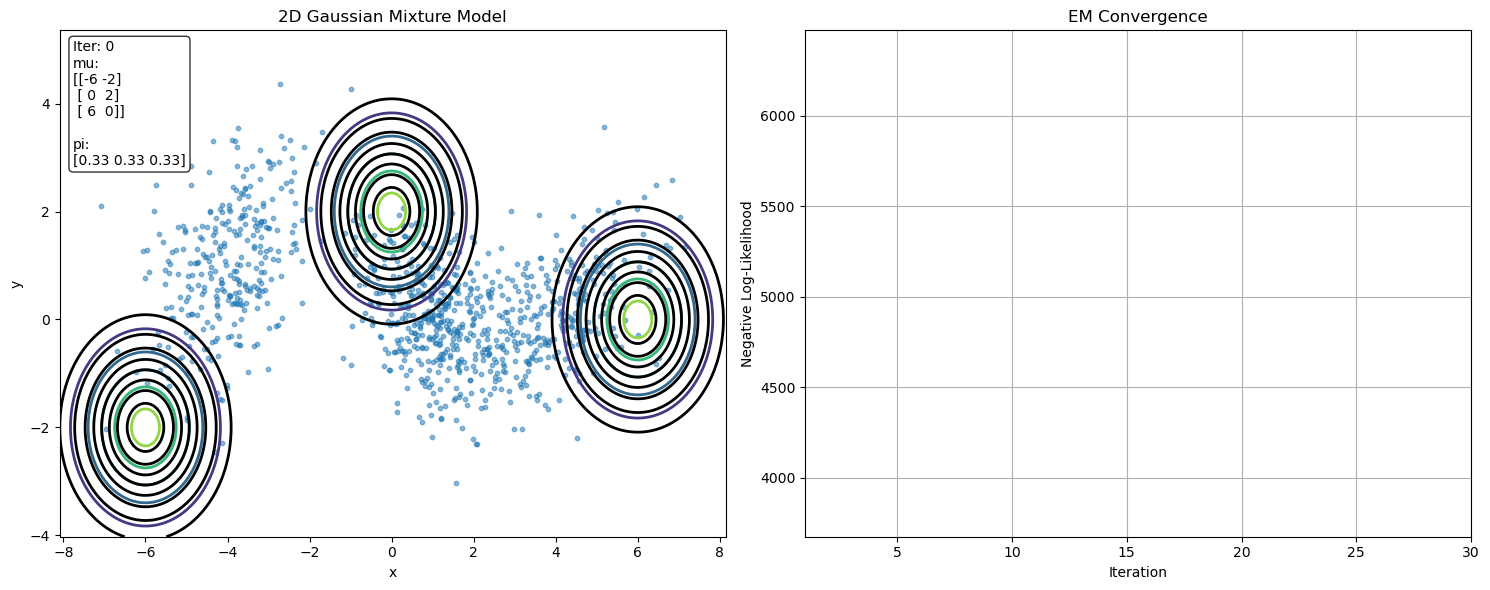

In [5]:
from scipy.stats import multivariate_normal

# Plotting and animation
fig = plt.figure(figsize=(15,6))
axis1 = fig.add_subplot(1,2,1)
axis2 = fig.add_subplot(1,2,2)

# Grid for drawing contours
xgrid = np.linspace(x[:,0].min()-1,
                    x[:,0].max()+1,
                    200)

ygrid = np.linspace(x[:,1].min()-1,
                    x[:,1].max()+1,
                    200)

Xg, Yg = np.meshgrid(xgrid, ygrid)
pos = np.dstack((Xg, Yg))

def update(frame):

    axis1.clear()
    axis2.clear()

    mu = mu_all[frame]
    sigma = sigma_all[frame]
    pi = pi_all[frame]

    # ---------- Left panel ----------
    axis1.scatter(
        x[:,0],
        x[:,1],
        s=10,
        alpha=0.5,
        label='Data'
    )

    gmm = np.zeros_like(Xg)

    for k in range(K):

        z = pi[k] * multivariate_normal.pdf(
            pos,
            mean=mu[k],
            cov=sigma[k]
        )

        gmm += z

        axis1.contour(
            Xg,
            Yg,
            z,
            levels=5,
            linewidths=2
        )

    axis1.contour(
        Xg,
        Yg,
        gmm,
        levels=8,
        colors='black',
        linewidths=2
    )

    axis1.set_xlim(
        x[:,0].min()-1,
        x[:,0].max()+1
    )

    axis1.set_ylim(
        x[:,1].min()-1,
        x[:,1].max()+1
    )

    axis1.set_xlabel('x')
    axis1.set_ylabel('y')
    axis1.set_title('2D Gaussian Mixture Model')

    axis1.text(
        0.02,
        0.98,
        f"Iter: {frame}\n"
        f"mu:\n{np.round(mu,2)}\n\n"
        f"pi:\n{np.round(pi,2)}",
        transform=axis1.transAxes,
        va='top',
        bbox=dict(
            boxstyle='round',
            facecolor='white',
            alpha=0.8
        )
    )

    # ---------- Right panel ----------
    n = min(frame, len(logL))

    if n > 0:
        axis2.plot(
            np.arange(1, n+1),
            nlogL[:n],
            marker='o'
        )

    axis2.set_xlim(1, NIter)
    axis2.set_ylim(
        min(nlogL)-10,
        max(nlogL)+10
    )

    axis2.set_xlabel('Iteration')
    axis2.set_ylabel('Negative Log-Likelihood')
    axis2.set_title('EM Convergence')
    axis2.grid(True)

    plt.tight_layout()

animate = FuncAnimation(
    fig,
    update,
    frames=15,
    interval=800
)

HTML(animate.to_jshtml())

In [7]:
animate.save("2dEM.gif")

<Figure size 640x480 with 0 Axes>